# 📘 Deep Learning Text Generation — Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **beginners** to understand how sequence models learn:
- Grammar and sentence structure
- Contextual word dependencies
- Next-word prediction
- Text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

---

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

# 📦 Step 1: Import Libraries

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Step 2: Load and Clean Text Corpus

We define a small paragraph as our training corpus.
The `.strip()` call removes leading/trailing whitespace so there are no empty tokens.

In [14]:
# --- Raw corpus text ---
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

cleaned_lines = [line.strip() for line in corpus.strip().split('\n') if line.strip()]
cleaned_corpus = '\n'.join(cleaned_lines)

print("--- Cleaned Corpus ---")
print(cleaned_corpus)

tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned_corpus])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size (total_words):", total_words)
print("Word → Index mapping (sample):")
for word, idx in list(tokenizer.word_index.items())[:8]:
    print(f"  '{word}' → {idx}")

--- Cleaned Corpus ---
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences

Vocabulary size (total_words): 37
Word → Index mapping (sample):
  'deep' → 1
  'learning' → 2
  'is' → 3
  'lstm' → 4
  'models' → 5
  'transforming' → 6
  'artificial' → 7
  'intelligence' → 8


# 🔤 Step 3: Build N-Gram Sequences + Padding

For each line we slide a window and collect all prefix sub-sequences.
Example for `"deep learning is"` →
- `[deep, learning]`
- `[deep, learning, is]`

Then we **pad** all sequences to the same length so the model receives uniform input.

In [15]:
input_sequences = []

for line in cleaned_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]   
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]    # shape: (num_samples, max_len - 1)
y = input_sequences[:, -1]     # shape: (num_samples,)

print("Total n-gram sequences created:", len(input_sequences))
print("Max sequence length (max_len):", max_len)
print("X shape:", X.shape, "  ← input to the model")
print("y shape:", y.shape, "  ← target word index")

print("\nSample X[0] (padded):", X[0])
print("Sample y[0] (target word index):", y[0])

Total n-gram sequences created: 35
Max sequence length (max_len): 8
X shape: (35, 7)   ← input to the model
y shape: (35,)   ← target word index

Sample X[0] (padded): [0 0 0 0 0 0 1]
Sample y[0] (target word index): 2


# 🧠 Step 4: Build Three Models

All three models share the **same architecture skeleton**:
```
Embedding → [RNN / LSTM / GRU] → Dense(softmax)
```
- **Embedding**: turns integer tokens into dense vector representations
- **Recurrent layer**: learns sequential patterns over time
- **Dense(softmax)**: outputs a probability for every word in vocabulary
---
## Model 1 — Vanilla RNN
The simplest sequential model. It suffers from **vanishing gradients** and struggles to remember words that appeared many steps back.

In [16]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model 2 — LSTM (Long Short-Term Memory)
Uses three gates — **input, forget, output** — to decide what to remember and what to discard.
This makes it much better at learning long-range dependencies.

In [17]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model 3 — GRU (Gated Recurrent Unit)
Uses only two gates — **reset and update** — making it faster to train than LSTM
while often achieving comparable performance.

In [18]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🏋️ Step 5: Compile and Train All Three Models
- Loss: `sparse_categorical_crossentropy` — used when labels are plain integers (not one-hot)
- Optimizer: `adam` — adaptive learning rate, same config for all three models
- `verbose=0` — suppresses per-epoch output to keep the notebook clean

In [19]:
compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.compile(**compile_args)
print("Training Vanilla RNN...")
rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print(f"  Final loss: {rnn_history.history['loss'][-1]:.4f}  |  Final accuracy: {rnn_history.history['accuracy'][-1]:.4f}")

lstm_model.compile(**compile_args)
print("Training LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print(f"  Final loss: {lstm_history.history['loss'][-1]:.4f}  |  Final accuracy: {lstm_history.history['accuracy'][-1]:.4f}")

gru_model.compile(**compile_args)
print("Training GRU...")
gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print(f"  Final loss: {gru_history.history['loss'][-1]:.4f}  |  Final accuracy: {gru_history.history['accuracy'][-1]:.4f}")

print("\n✅ All three models trained successfully!")

Training Vanilla RNN...
  Final loss: 0.7980  |  Final accuracy: 0.9429
Training LSTM...
  Final loss: 1.5273  |  Final accuracy: 0.6571
Training GRU...
  Final loss: 1.1557  |  Final accuracy: 0.7714

✅ All three models trained successfully!


# 📉 Step 6: Plot Training Loss Comparison
A lower and more stable loss curve means the model is learning better.
LSTM and GRU should generally converge faster than Vanilla RNN.

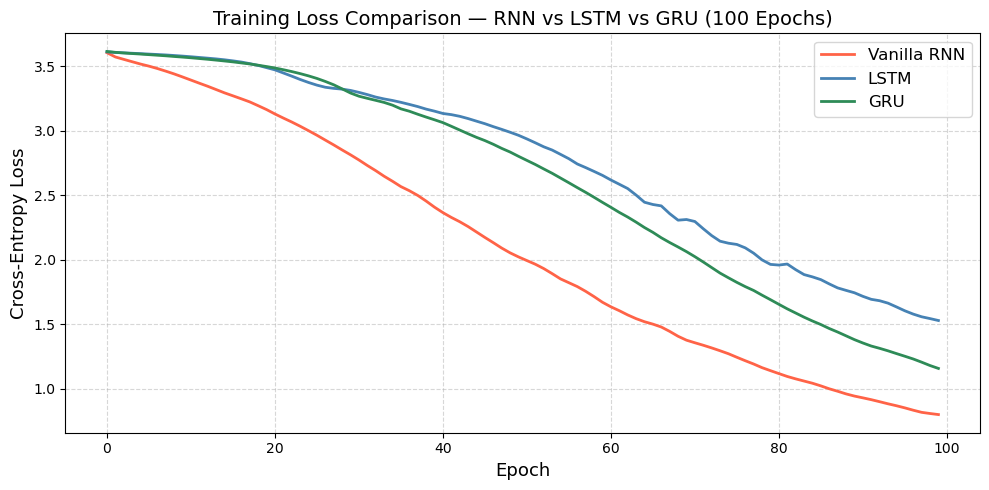

Interpretation:
  - A steeper early drop means faster learning
  - A lower final loss means better convergence
  - Smoother curve = more stable gradient flow


In [20]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history['loss'],  label='Vanilla RNN', color='tomato',    linewidth=2)
plt.plot(lstm_history.history['loss'], label='LSTM',        color='steelblue', linewidth=2)
plt.plot(gru_history.history['loss'],  label='GRU',         color='seagreen',  linewidth=2)

plt.xlabel("Epoch",         fontsize=13)
plt.ylabel("Cross-Entropy Loss", fontsize=13)
plt.title("Training Loss Comparison — RNN vs LSTM vs GRU (100 Epochs)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - A steeper early drop means faster learning")
print("  - A lower final loss means better convergence")
print("  - Smoother curve = more stable gradient flow")

# ✍️ Step 7: Text Generation Function
How it works step by step:
1. Tokenize the seed phrase into integer indices
2. Pad the token list to match training input length
3. Feed into the model → get probability distribution over vocabulary
4. `np.argmax(...)` selects the index with the highest probability
5. Look up that index in the word dictionary to get the actual word
6. Append the predicted word to the seed and repeat

In [21]:
def generate_text(model, seed_text, next_words=5):
    """
    Generates text by predicting one word at a time.

    Parameters:
        model      : trained Keras model (RNN, LSTM, or GRU)
        seed_text  : starting phrase (string)
        next_words : how many words to generate (int)

    Returns:
        Full generated string (seed + predicted words)
    """
    for _ in range(next_words):
        # Step 1: Convert current text to token list
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Step 2: Pad to match training input shape
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')

        # Step 3: Get probability scores for every word in vocabulary
        probabilities = model.predict(token_list, verbose=0)  # shape: (1, total_words)

        # Step 4: Pick the word index with the highest probability
        predicted_index = np.argmax(probabilities, axis=-1)[0]

        # Step 5: Reverse look-up: integer index → actual word string
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break

        # Step 6: Append word and continue loop
        seed_text = seed_text + " " + predicted_word

    return seed_text

print("generate_text() function defined successfully.")

generate_text() function defined successfully.


## 🧪 Generate Text Samples — Shared Seed Phrase

All three models receive the **same seed phrase** so the outputs are directly comparable.

In [22]:
seed_phrase = "deep learning"

rnn_output  = generate_text(rnn_model,  seed_phrase, next_words=5)
lstm_output = generate_text(lstm_model, seed_phrase, next_words=5)
gru_output  = generate_text(gru_model,  seed_phrase, next_words=5)

print("Seed phrase:", f'"{ seed_phrase }"')
print()
print("RNN  :", rnn_output)
print("LSTM :", lstm_output)
print("GRU  :", gru_output)

Seed phrase: "deep learning"

RNN  : deep learning is transforming artificial intelligence sentences
LSTM : deep learning learning can generate meaningful sentences
GRU  : deep learning models can generate sentences sentences


---
# 📚 Student Learning Tasks

Below are all **5 beginner-level customization tasks** implemented from scratch.
Each task is in its own cell so you can experiment independently.

---

## ✅ Task 1 — Replace Corpus with a Custom Paragraph

In [23]:
custom_corpus = '''
the sun rises in the east and sets in the west
birds fly high in the sky every morning
rivers flow through forests and reach the sea
mountains stand tall and proud under the blue sky
the wind carries seeds across the open fields
nature is beautiful and full of wonder every day
'''

custom_lines = [line.strip() for line in custom_corpus.strip().split('\n') if line.strip()]

custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts(custom_lines)
custom_total_words = len(custom_tokenizer.word_index) + 1

custom_sequences = []
for line in custom_lines:
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        custom_sequences.append(token_list[:i + 1])

custom_max_len = max(len(seq) for seq in custom_sequences)
custom_sequences = pad_sequences(custom_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_sequences[:, :-1]
y_custom  = custom_sequences[:, -1]

print("Custom vocabulary size:", custom_total_words)
print("Custom X shape:", X_custom.shape)
print("Ready to train on custom corpus! ✅")

Custom vocabulary size: 40
Custom X shape: (47, 10)
Ready to train on custom corpus! ✅


## ✅ Task 2 — Upscale Embedding Dimensions (32 → 64)

In [24]:
embedding_dim = 64   # was 32, now doubled

rnn_model_t2 = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

lstm_model_t2 = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

gru_model_t2 = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

print(f"Embedding dimension set to: {embedding_dim}")
print("Models with upscaled embeddings ready. ✅")
rnn_model_t2.summary()

Embedding dimension set to: 64
Models with upscaled embeddings ready. ✅


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## ✅ Task 3 — Expand Training to 200 Epochs

Training RNN for 200 epochs...
  RNN  final loss: 0.0443
Training LSTM for 200 epochs...
  LSTM final loss: 0.0967
Training GRU  for 200 epochs...
  GRU  final loss: 0.0450


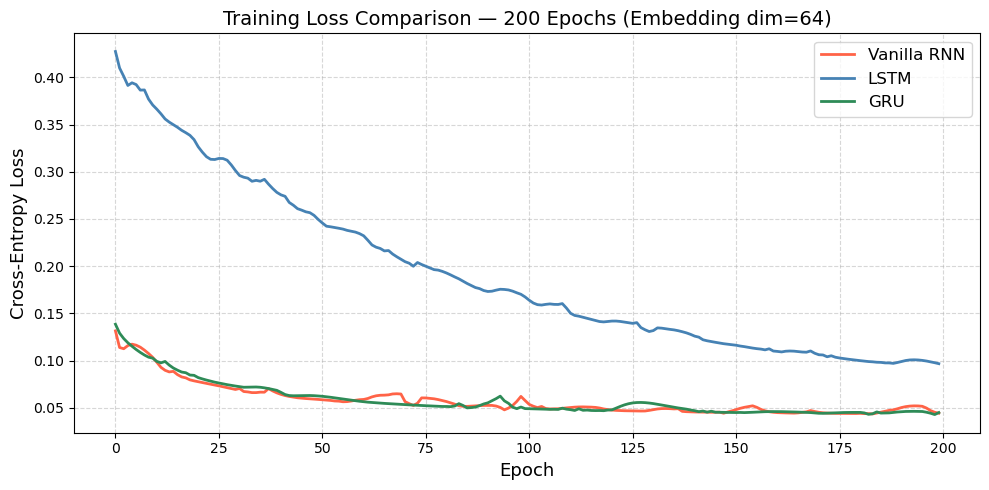

200-epoch training complete! ✅


In [26]:
num_epochs = 200   # was 100, now doubled

compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model_t2.compile(**compile_args)
print(f"Training RNN for {num_epochs} epochs...")
rnn_hist_200 = rnn_model_t2.fit(X, y, epochs=num_epochs, verbose=0)
print(f"  RNN  final loss: {rnn_hist_200.history['loss'][-1]:.4f}")

lstm_model_t2.compile(**compile_args)
print(f"Training LSTM for {num_epochs} epochs...")
lstm_hist_200 = lstm_model_t2.fit(X, y, epochs=num_epochs, verbose=0)
print(f"  LSTM final loss: {lstm_hist_200.history['loss'][-1]:.4f}")

gru_model_t2.compile(**compile_args)
print(f"Training GRU  for {num_epochs} epochs...")
gru_hist_200 = gru_model_t2.fit(X, y, epochs=num_epochs, verbose=0)
print(f"  GRU  final loss: {gru_hist_200.history['loss'][-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(rnn_hist_200.history['loss'],  label='Vanilla RNN', color='tomato',    linewidth=2)
plt.plot(lstm_hist_200.history['loss'], label='LSTM',        color='steelblue', linewidth=2)
plt.plot(gru_hist_200.history['loss'],  label='GRU',         color='seagreen',  linewidth=2)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Cross-Entropy Loss", fontsize=13)
plt.title("Training Loss Comparison — 200 Epochs (Embedding dim=64)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("200-epoch training complete! ✅")

## ✅ Task 4 — Widen Hidden Layers (64 → 128 units)

In [27]:
hidden_units = 128   # was 64

rnn_model_t4 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(hidden_units),
    Dense(total_words, activation='softmax')
])

lstm_model_t4 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(hidden_units),
    Dense(total_words, activation='softmax')
])

gru_model_t4 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(hidden_units),
    Dense(total_words, activation='softmax')
])

compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model_t4.compile(**compile_args)
rnn_hist_t4 = rnn_model_t4.fit(X, y, epochs=100, verbose=0)

lstm_model_t4.compile(**compile_args)
lstm_hist_t4 = lstm_model_t4.fit(X, y, epochs=100, verbose=0)

gru_model_t4.compile(**compile_args)
gru_hist_t4 = gru_model_t4.fit(X, y, epochs=100, verbose=0)

print(f"Hidden units = {hidden_units}")
print(f"RNN  final loss: {rnn_hist_t4.history['loss'][-1]:.4f}")
print(f"LSTM final loss: {lstm_hist_t4.history['loss'][-1]:.4f}")
print(f"GRU  final loss: {gru_hist_t4.history['loss'][-1]:.4f}")
print("Models with 128 hidden units trained. ✅")

Hidden units = 128
RNN  final loss: 0.3712
LSTM final loss: 1.1556
GRU  final loss: 0.6616
Models with 128 hidden units trained. ✅


## ✅ Task 5 — Generate 10 Words per Seed Prompt

In [ ]:
num_words_to_generate = 10   # was 5

seed_phrase = "deep learning"

rnn_10  = generate_text(rnn_model_t4,  seed_phrase, next_words=num_words_to_generate)
lstm_10 = generate_text(lstm_model_t4, seed_phrase, next_words=num_words_to_generate)
gru_10  = generate_text(gru_model_t4,  seed_phrase, next_words=num_words_to_generate)

print(f"Seed: '{seed_phrase}' | Generating {num_words_to_generate} words")
print()
print("RNN  (128 units, 10 words):", rnn_10)
print("LSTM (128 units, 10 words):", lstm_10)
print("GRU  (128 units, 10 words):", gru_10)

---
# ✅ Conclusion

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Vanilla RNN** | Simple, fast, easy to understand | Vanishing gradients, poor long-term memory |
| **LSTM** | Excellent long-range dependency learning | More parameters, slower to train |
| **GRU** | Similar accuracy to LSTM, fewer gates | Slightly less memory control than LSTM |
---